<a href="https://colab.research.google.com/github/sathundorn/gold-price-forecasting/blob/main/Chornos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install chronos-forecasting yfinance pandas matplotlib torch

1. Downloading Recent Gold Price Data (2024 - 2026)...
2. Loading Chronos Model...
3. Forecasting next 30 days (True Out-of-Sample)...

📊 True Out-of-Sample Evaluation
Chronos MAPE (Recent Data): 7.68%



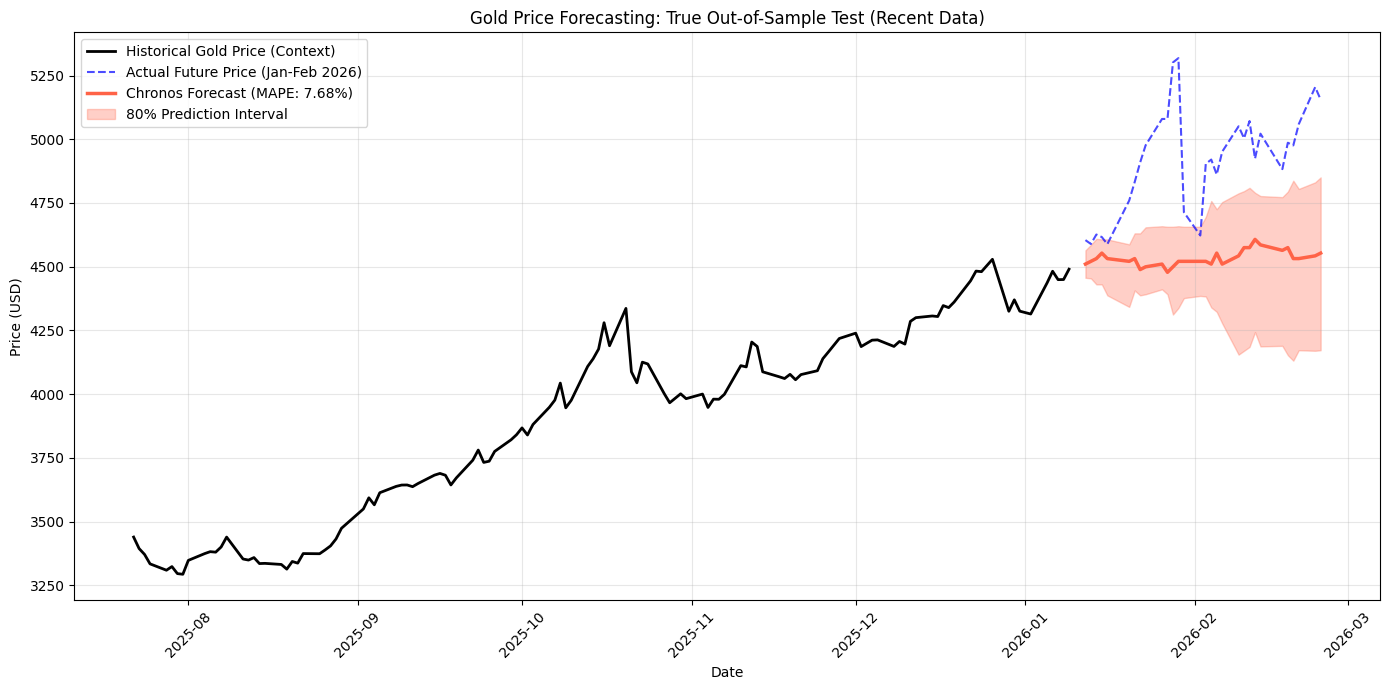

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import torch
from chronos import ChronosPipeline
from sklearn.metrics import mean_absolute_percentage_error
import warnings

warnings.filterwarnings('ignore')

# 1. ดึงข้อมูลราคาทองคำ (GC=F) ตั้งแต่ต้นปี 2024 ถึงปัจจุบัน
print("1. Downloading Recent Gold Price Data (2024 - 2026)...")
gold_data = yf.download('GC=F', start='2024-01-01', end='2026-02-25', progress=False)
df = gold_data[['Close']].reset_index()
df.columns = ['Date', 'Price']

# 2. แบ่งข้อมูล Train / Test (หั่น 30 วันทำการล่าสุดออกมาเป็นข้อสอบ)
prediction_length = 30
train_df = df.iloc[:-prediction_length]
test_df = df.iloc[-prediction_length:]

# 3. โหลดโมเดล Chronos
print("2. Loading Chronos Model...")
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",
    torch_dtype=torch.bfloat16,
)

# 4. ให้โมเดลทำนาย (Out-of-sample จริงๆ)
print(f"3. Forecasting next {prediction_length} days (True Out-of-Sample)...")
context = torch.tensor(train_df['Price'].values)

forecast = pipeline.predict(
    context,
    prediction_length=prediction_length,
    num_samples=20,
)

# ดึงค่ามัธยฐานและช่วงความเชื่อมั่น
low, median, high = torch.quantile(forecast[0], torch.tensor([0.1, 0.5, 0.9]), dim=0)

y_pred = median.numpy()
y_true = test_df['Price'].values

# 5. คำนวณค่า MAPE
mape = mean_absolute_percentage_error(y_true, y_pred) * 100

print(f"\n=====================================")
print(f"📊 True Out-of-Sample Evaluation")
print(f"Chronos MAPE (Recent Data): {mape:.2f}%")
print(f"=====================================\n")

# 6. พล็อตกราฟผลลัพธ์
plt.figure(figsize=(14, 7))

# พล็อตข้อมูลอดีต (แสดง 120 วันล่าสุดให้เห็นเทรนด์ก่อนหน้าชัดๆ)
plt.plot(train_df['Date'].tail(120), train_df['Price'].tail(120), color="black", label="Historical Gold Price (Context)", linewidth=2)

# พล็อตข้อมูลจริงที่เพิ่งเกิดขึ้น (Test Set)
plt.plot(test_df['Date'], y_true, color="blue", linestyle="--", alpha=0.7, label="Actual Future Price (Jan-Feb 2026)")

# พล็อตเส้นที่พยากรณ์ได้
plt.plot(test_df['Date'], y_pred, color="tomato", linewidth=2.5, label=f"Chronos Forecast (MAPE: {mape:.2f}%)")
plt.fill_between(test_df['Date'], low.numpy(), high.numpy(), color="tomato", alpha=0.3, label="80% Prediction Interval")

plt.title("Gold Price Forecasting: True Out-of-Sample Test (Recent Data)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1. Downloading Recent Gold Price Data...
2. Loading Chronos Model...


3. Forecasting 90 days into the future...

📊 Forecast Horizon Comparison
Short-Term (14 Days) MAPE: 3.35%
Long-Term (90 Days) MAPE : 5.88%



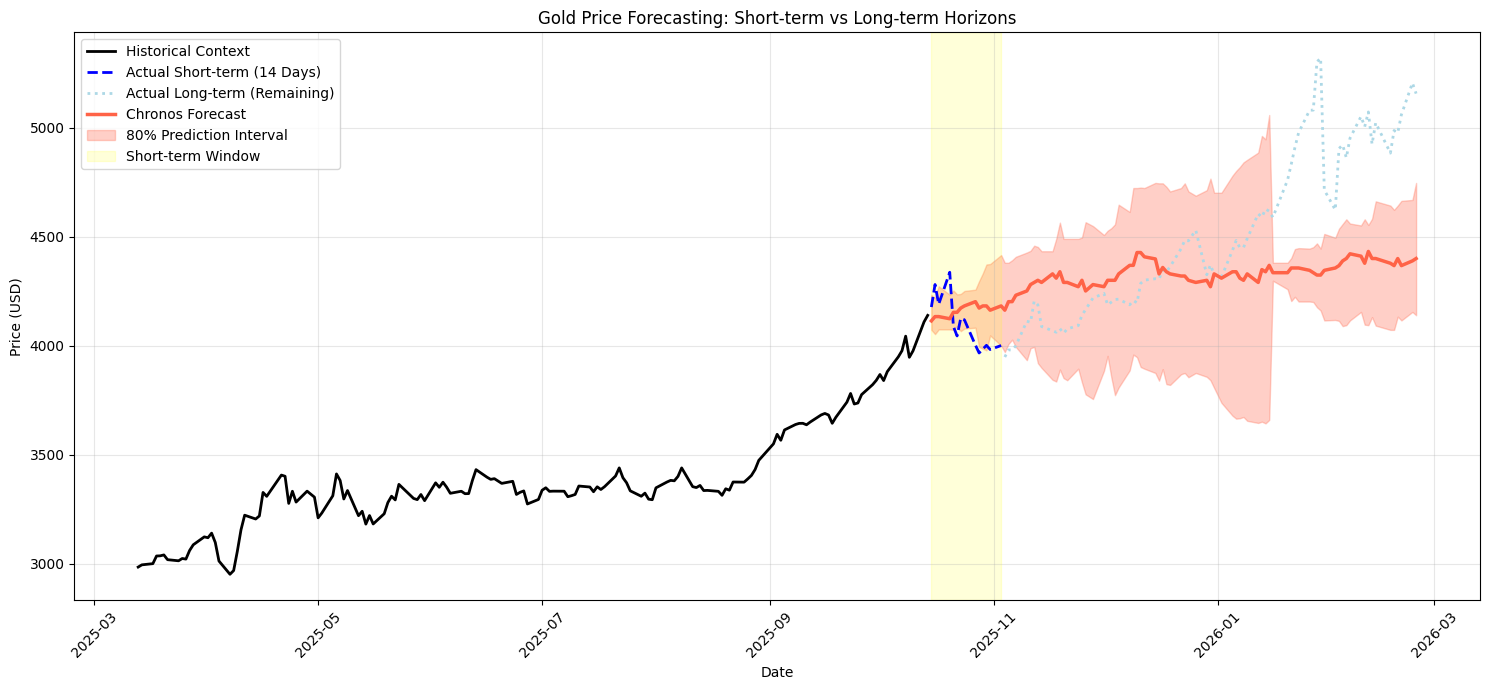

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import torch
from chronos import ChronosPipeline
from sklearn.metrics import mean_absolute_percentage_error
import warnings

warnings.filterwarnings('ignore')

# 1. ดึงข้อมูลราคาทองคำล่าสุด (ตั้งแต่ปี 2023 - ปัจจุบัน)
print("1. Downloading Recent Gold Price Data...")
gold_data = yf.download('GC=F', start='2023-01-01', end='2026-02-25', progress=False)
df = gold_data[['Close']].reset_index()
df.columns = ['Date', 'Price']

# 2. ตั้งค่าระยะเวลา Short-term และ Long-term
long_term_days = 90
short_term_days = 14

# หั่นชุดข้อมูล (เก็บ 90 วันล่าสุดไว้เป็น Test)
train_df = df.iloc[:-long_term_days]
test_df = df.iloc[-long_term_days:]

# 3. โหลดโมเดล Chronos
print("2. Loading Chronos Model...")
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",
    torch_dtype=torch.bfloat16,
)

# 4. ให้โมเดลพยากรณ์ทีเดียว 90 วัน (Long-term)
print(f"3. Forecasting {long_term_days} days into the future...")
context = torch.tensor(train_df['Price'].values)
forecast = pipeline.predict(
    context,
    prediction_length=long_term_days,
    num_samples=20,
)

low, median, high = torch.quantile(forecast[0], torch.tensor([0.1, 0.5, 0.9]), dim=0)

y_pred_long = median.numpy()
y_true_long = test_df['Price'].values

# แยกชุดข้อมูล Short-term (14 วันแรกของผลพยากรณ์)
y_pred_short = y_pred_long[:short_term_days]
y_true_short = y_true_long[:short_term_days]

# 5. คำนวณค่า MAPE เปรียบเทียบ
mape_short = mean_absolute_percentage_error(y_true_short, y_pred_short) * 100
mape_long = mean_absolute_percentage_error(y_true_long, y_pred_long) * 100

print(f"\n=====================================")
print(f"📊 Forecast Horizon Comparison")
print(f"Short-Term (14 Days) MAPE: {mape_short:.2f}%")
print(f"Long-Term (90 Days) MAPE : {mape_long:.2f}%")
print(f"=====================================\n")

# 6. พล็อตกราฟเปรียบเทียบให้เห็นภาพ
plt.figure(figsize=(15, 7))

# พล็อตข้อมูลอดีต
plt.plot(train_df['Date'].tail(150), train_df['Price'].tail(150), color="black", label="Historical Context", linewidth=2)

# พล็อตข้อมูลจริงในอนาคต (แยกสีช่วง 14 วัน กับ 90 วัน)
plt.plot(test_df['Date'].iloc[:short_term_days], y_true_short, color="blue", linestyle="--", linewidth=2, label="Actual Short-term (14 Days)")
plt.plot(test_df['Date'].iloc[short_term_days:], test_df['Price'].iloc[short_term_days:], color="lightblue", linestyle=":", linewidth=2, label="Actual Long-term (Remaining)")

# พล็อตเส้นพยากรณ์
plt.plot(test_df['Date'], y_pred_long, color="tomato", linewidth=2.5, label="Chronos Forecast")
plt.fill_between(test_df['Date'], low.numpy(), high.numpy(), color="tomato", alpha=0.3, label="80% Prediction Interval")

# ไฮไลต์โซน Short-term ให้เห็นชัดๆ
plt.axvspan(test_df['Date'].iloc[0], test_df['Date'].iloc[short_term_days-1], color='yellow', alpha=0.15, label="Short-term Window")

plt.title("Gold Price Forecasting: Short-term vs Long-term Horizons")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1. Downloading Gold Price Data...
2. Loading Chronos Model (t5-base)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/806M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

3. Evaluating on Test Set (30 days) using ROLLING FORECAST...


Forecasting Day-by-Day: 100%|██████████| 30/30 [1:20:12<00:00, 160.41s/it]


📊 Test Set (Rolling 1-Step) Metrics:
   - MAPE:      2.03%
   - RMSE:      147.40 USD
   - MAE:       99.67 USD
   - Direction: 37.93%

4. Forecasting Next 7 Days...


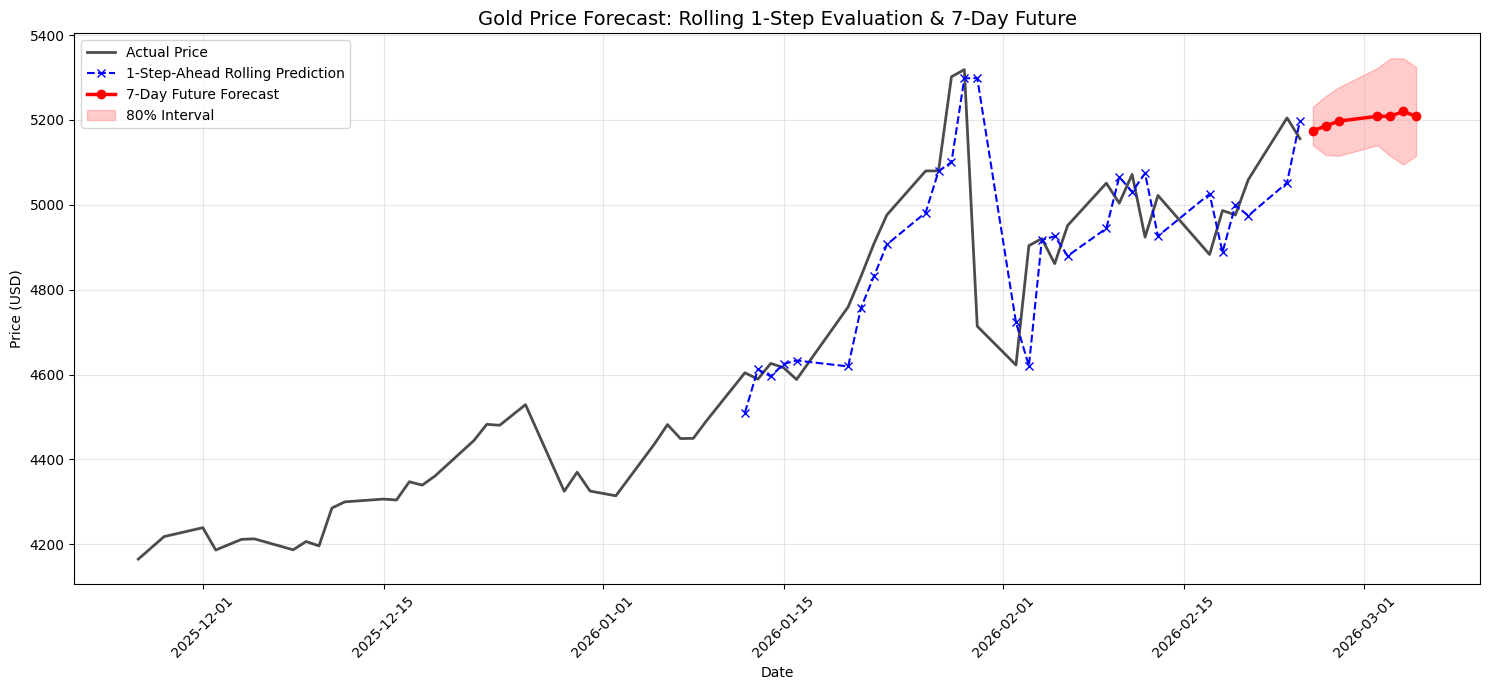

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import torch
from chronos import ChronosPipeline
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error
from tqdm import tqdm # เอาไว้แสดง Progress Bar เพราะมันต้องรันทีละรอบ
import warnings

warnings.filterwarnings('ignore')

# --- ฟังก์ชันคำนวณ Metrics ---
def calculate_metrics(y_true, y_pred, name=""):
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    if len(y_true) > 1:
        dir_true = np.sign(np.diff(y_true))
        dir_pred = np.sign(np.diff(y_pred))
        direction_acc = np.mean(dir_true == dir_pred) * 100
    else:
        direction_acc = 0.0

    print(f"📊 {name} Metrics:")
    print(f"   - MAPE:      {mape:.2f}%")
    print(f"   - RMSE:      {rmse:.2f} USD")
    print(f"   - MAE:       {mae:.2f} USD")
    print(f"   - Direction: {direction_acc:.2f}%\n")
    return mape, rmse, mae, direction_acc

# 1. ดึงข้อมูล
print("1. Downloading Gold Price Data...")
gold_data = yf.download('GC=F', start='2024-01-01', end='2026-02-25', progress=False)
if isinstance(gold_data.columns, pd.MultiIndex):
    gold_data.columns = gold_data.columns.get_level_values(0)
df = gold_data[['Close']].reset_index()
df.columns = ['Date', 'Price']

# 2. ตั้งค่าช่วงทดสอบ
pred_length = 30 # จะทำการ Test 30 วันย้อนหลัง
test_df = df.iloc[-pred_length:].copy()
historical_data = df.iloc[:-pred_length]['Price'].values.tolist()

# 3. โหลดโมเดล
print("2. Loading Chronos Model (t5-base)...")
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-base",
    device_map="cpu",
    torch_dtype=torch.bfloat16,
)

gen_kwargs = {
    "temperature": 0.5,
    "top_p": 0.95,
    "num_samples": 40
}

# 4. ทำ Rolling Forecast (ทำนายทีละ 1 วันล่วงหน้า)
print(f"3. Evaluating on Test Set ({pred_length} days) using ROLLING FORECAST...")
rolling_predictions = []

# จำลองการเดินหน้าทีละวัน
for i in tqdm(range(pred_length), desc="Forecasting Day-by-Day"):
    # ใช้ข้อมูลทั้งหมดจนถึงเมื่อวาน
    current_context = torch.tensor(historical_data)

    # สั่งให้ทำนายแค่ 1 วันข้างหน้า
    forecast = pipeline.predict(
        current_context,
        prediction_length=1,
        **gen_kwargs
    )

    # ดึงค่าพยากรณ์ของวันรุ่งขึ้น
    pred_1_day = torch.quantile(forecast[0], 0.5, dim=0).numpy()[0]
    rolling_predictions.append(pred_1_day)

    # เลื่อนหน้าต่าง: เอาข้อมูลจริงของวันนี้ ใส่เข้าไปในประวัติเพื่อใช้ทำนายวันพรุ่งนี้
    actual_price_today = test_df.iloc[i]['Price']
    historical_data.append(actual_price_today)

test_df['Rolling_Pred'] = rolling_predictions

# 5. คำนวณ Metrics (เทียบของจริง 30 วัน กับ ผลจาก Rolling 30 วัน)
calculate_metrics(test_df['Price'].values, test_df['Rolling_Pred'].values, "Test Set (Rolling 1-Step)")

# 6. พยากรณ์อนาคต 7 วันจริงๆ (Future)
print("4. Forecasting Next 7 Days...")
forecast_future = pipeline.predict(
    torch.tensor(df['Price'].values),
    prediction_length=7,
    **gen_kwargs
)
low_f, median_f, high_f = torch.quantile(forecast_future[0], torch.tensor([0.1, 0.5, 0.9]), dim=0)
future_dates = pd.date_range(start=df['Date'].iloc[-1] + pd.Timedelta(days=1), periods=7, freq='B')

# 7. พล็อตกราฟ
plt.figure(figsize=(15, 7))

# พล็อตข้อมูลจริง (ซูมดู 60 วันล่าสุด)
zoom_df = df.tail(60)
plt.plot(zoom_df['Date'], zoom_df['Price'], color="black", label="Actual Price", linewidth=2, alpha=0.7)

# พล็อต Rolling Predictions
plt.plot(test_df['Date'], test_df['Rolling_Pred'], color="blue", marker='x', linestyle="--", linewidth=1.5, label="1-Step-Ahead Rolling Prediction")

# พล็อต Future Forecast
plt.plot(future_dates, median_f.numpy(), color="red", marker='o', linewidth=2.5, label="7-Day Future Forecast")
plt.fill_between(future_dates, low_f.numpy(), high_f.numpy(), color="red", alpha=0.2, label="80% Interval")

plt.title("Gold Price Forecast: Rolling 1-Step Evaluation & 7-Day Future", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()